# Análise Exploratória — ENEM 2023

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set_theme(style='whitegrid', palette='muted')

# Carregar os dados
df = pd.read_csv('../data/ENEM_2023.csv')
print(df.shape)
df.head()

(127574, 18)


,Age,Genre,Race,School_Type,State,Region,Score_Natural_Sciences,Score_Human_Sciences,Score_Languages,Score_Mathematics,Score_Essay,Mean_Score,Father_Education,Mother_Education,Family_Income,Has_Cell_Phone,Has_Computer,Has_Internet
0,17,Female,Pardo (Mixed),Public,CE,Northeast,459.0,508.5,507.2,466.7,880.0,564.28,Incomplete Secondary (High School),Incomplete Secondary (High School),R$ 1320 - 1980,3,0,Yes
1,18,Female,Pardo (Mixed),Public,CE,Northeast,402.5,379.2,446.9,338.3,560.0,425.38,Incomplete Primary (5th grade),Incomplete Primary (5th grade),Up to R$ 1320,1,0,No
2,18,Male,Pardo (Mixed),Public,PR,South,608.2,667.6,607.9,691.9,780.0,671.12,Incomplete Secondary (High School),Complete Secondary (High School),R$ 1980 - 2640,1,1,Yes
3,19,Female,White,Public,PA,North,515.7,553.1,544.4,437.0,880.0,586.04,Complete Secondary (High School),Complete Secondary (High School),Up to R$ 1320,3,0,Yes
4,18,Male,White,Public,SP,Southeast,523.8,576.3,596.5,628.1,600.0,584.94,Incomplete Primary (9th grade),Incomplete Primary (9th grade),R$ 1980 - 2640,1,0,Yes


In [104]:
# Análise exploratória
print(df.dtypes)
print('\n')
print(df.isnull().sum())
print('\n')
df.describe()

Age                           str
Genre                         str
Race                          str
School_Type                   str
State                         str
Region                        str
Score_Natural_Sciences    float64
Score_Human_Sciences      float64
Score_Languages           float64
Score_Mathematics         float64
Score_Essay               float64
Mean_Score                float64
Father_Education              str
Mother_Education              str
Family_Income                 str
Has_Cell_Phone              int64
Has_Computer                int64
Has_Internet                  str
dtype: object


Age                       0
Genre                     0
Race                      0
School_Type               0
State                     0
Region                    0
Score_Natural_Sciences    0
Score_Human_Sciences      0
Score_Languages           0
Score_Mathematics         0
Score_Essay               0
Mean_Score                0
Father_Education          0
Mother_E

,Score_Natural_Sciences,Score_Human_Sciences,Score_Languages,Score_Mathematics,Score_Essay,Mean_Score,Has_Cell_Phone,Has_Computer
count,127574.000000,127574.000000,127574.000000,127574.000000,127574.000000,127574.000000,127574.000000,127574.000000
mean,493.852424,527.929316,523.010379,540.499255,662.987756,549.655826,2.619147,0.687844
std,83.167040,83.856683,72.294725,127.663655,209.790684,94.785843,1.095255,0.915637
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,439.500000,475.300000,478.400000,439.700000,560.000000,486.320000,2.000000,0.000000
50%,491.200000,534.500000,528.100000,532.700000,680.000000,551.230000,3.000000,0.000000
75%,547.600000,586.900000,573.500000,634.800000,840.000000,616.700000,3.000000,1.000000
max,844.300000,823.000000,801.100000,958.600000,1000.000000,847.060000,4.000000,4.000000


## Pergunta 1 — Qual a média geral de notas por região do Brasil?

In [105]:
media_por_regiao = df.groupby('Region')['Mean_Score'].mean().sort_values(ascending=False)
print(media_por_regiao)

Region
Southeast    571.703522
South        566.994963
Midwest      550.982434
Northeast    530.597279
North        528.816505
Name: Mean_Score, dtype: float64


## Pergunta 2 - Alunos de escola pública vs privada: qual a diferença média em Matemática?


In [106]:
media_mat_por_tipo_escola = df.groupby('School_Type')['Score_Mathematics'].mean()
print(media_mat_por_tipo_escola)

# Acessando os valores diretamente do seu resultado
diferenca = media_mat_por_tipo_escola['Private'] - media_mat_por_tipo_escola['Public']
print(f"\nA diferença real é de {diferenca:.2f} pontos.")

School_Type
Not informed    473.100000
Private         647.759209
Public          517.382690
Name: Score_Mathematics, dtype: float64

A diferença real é de 130.38 pontos.


## Pergunta 3 - Qual o impacto da renda familiar na nota média? (agrupa por faixa de renda)


In [107]:
media_por_faixa_renda = df.groupby('Family_Income')['Mean_Score'].mean().sort_values(ascending=False)
print(media_por_faixa_renda)

Family_Income
Above R$ 26400      674.640569
R$ 19800 - 26400    662.295330
R$ 15840 - 19800    650.299898
R$ 13200 - 15840    641.488941
R$ 11880 - 13200    640.019793
R$ 10560 - 11880    631.841704
R$ 9240 - 10560     626.969572
R$ 7920 - 9240      619.768787
R$ 6600 - 7920      610.486286
R$ 5280 - 6600      605.042163
R$ 3960 - 5280      586.956792
R$ 3300 - 3960      577.585291
R$ 2640 - 3300      565.218772
R$ 1980 - 2640      552.316184
R$ 1320 - 1980      537.648876
Up to R$ 1320       509.409447
No Income           488.021415
Name: Mean_Score, dtype: float64


## Pergunta 4 - Existe diferença de desempenho entre homens e mulheres por área?

In [108]:
colunas_notas = ['Score_Languages', 'Score_Mathematics', 'Score_Human_Sciences', 'Score_Natural_Sciences', 'Score_Essay']
medias_por_genero = df.groupby('Genre')[colunas_notas].mean()
print(medias_por_genero)

        Score_Languages  Score_Mathematics  Score_Human_Sciences  \
Genre                                                              
Female       524.163703         527.473827            526.992999   
Male         520.974702         563.489820            529.581965   

        Score_Natural_Sciences  Score_Essay  
Genre                                        
Female              487.757310   682.715998  
Male                504.610622   628.166370  


## Pergunta 5 - Qual a distribuição de notas em Matemática? (histograma)

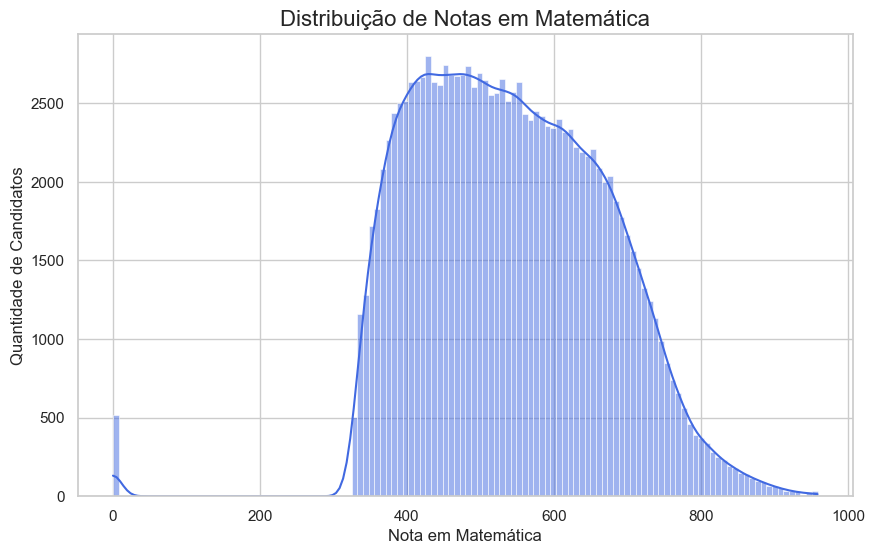

In [109]:
# 1. Definindo o tamanho da imagem
plt.figure(figsize=(10, 6))

# 2. Criando o histograma com a linha de densidade (KDE)
sns.histplot(data=df, x='Score_Mathematics', bins='auto', kde=True, color='royalblue')

# 3. Adicionando título e rótulos
plt.title('Distribuição de Notas em Matemática', fontsize=16)
plt.xlabel('Nota em Matemática', fontsize=12)
plt.ylabel('Quantidade de Candidatos', fontsize=12)

plt.show()

## Pergunta 6 - Estados do Nordeste vs resto do Brasil: como se comparam?


NE_vs_Resto
Nordeste           530.597279
Resto do Brasil    561.671945
Name: Mean_Score, dtype: float64


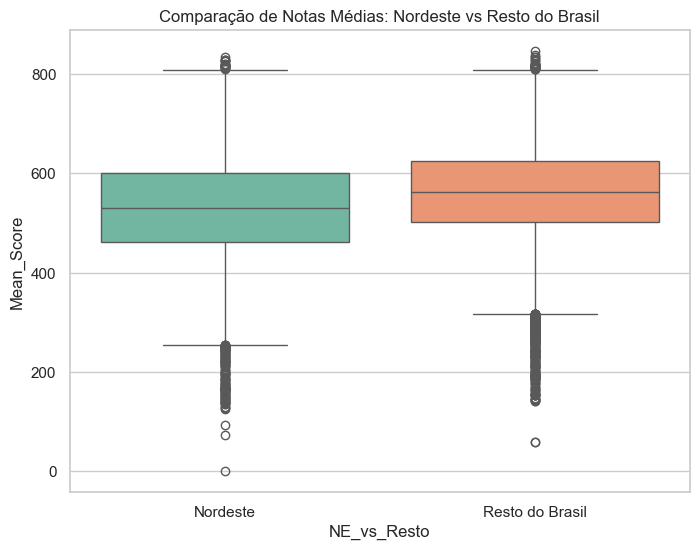

In [ ]:
# 1. Criando a variável de comparação
df['NE_vs_Resto'] = df['Region'].apply(lambda x: 'Nordeste' if x == 'Northeast' else 'Resto do Brasil')

# 2. Comparando as médias de forma rápida
comparativo = df.groupby('NE_vs_Resto')['Mean_Score'].mean()
print(comparativo)

# 3. Visualizando a distribuição com Seaborn
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='NE_vs_Resto', y='Mean_Score', 
            hue='NE_vs_Resto', legend=False, palette='Set2')
plt.title('Comparação de Notas Médias: Nordeste vs Resto do Brasil')
plt.xlabel('')
plt.ylabel('Nota Média')
plt.show()

## Pergunta 7 - Ter internet em casa faz diferença nas notas? Quantifica.


Has_Internet
No     494.479994
Yes    554.363457
Name: Mean_Score, dtype: float64

A diferença média é de 59.88 pontos entre quem tem e quem não tem internet em casa.
A diferença percentual é de 12.11% a mais para quem tem internet em casa.


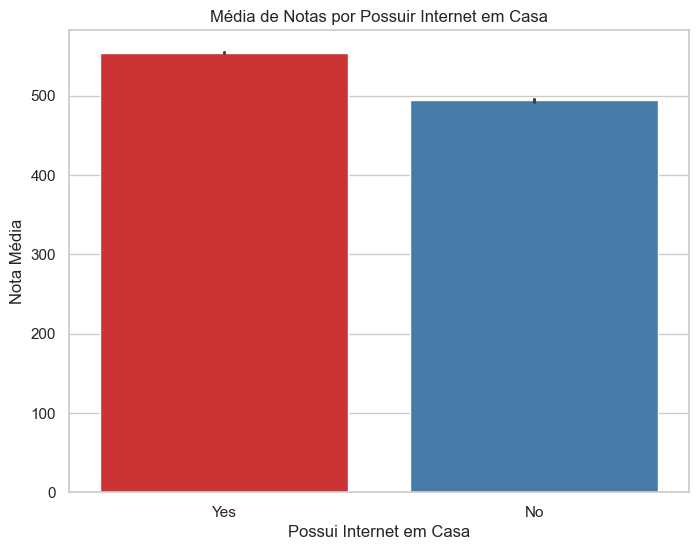

In [245]:
medias_por_possuir_internet = df.groupby('Has_Internet')['Mean_Score'].mean()
print(medias_por_possuir_internet)

# Quantificando a diferença
diferenca_pontos = medias_por_possuir_internet['Yes'] - medias_por_possuir_internet['No']
print(f"\nA diferença média é de {diferenca_pontos:.2f} pontos entre quem tem e quem não tem internet em casa.")

diferenca_percentual = (diferenca_pontos / medias_por_possuir_internet['No']) * 100
print(f"A diferença percentual é de {diferenca_percentual:.2f}% a mais para quem tem internet em casa.")

# Visualizando a diferença
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Has_Internet', y='Mean_Score',
            hue='Has_Internet', legend=False, palette='Set1')
plt.title('Média de Notas por Possuir Internet em Casa')
plt.xlabel('Possui Internet em Casa')
plt.ylabel('Nota Média')
plt.show()

## Pergunta 8 - Qual a correlação entre nota de Redação e nota de Matemática?


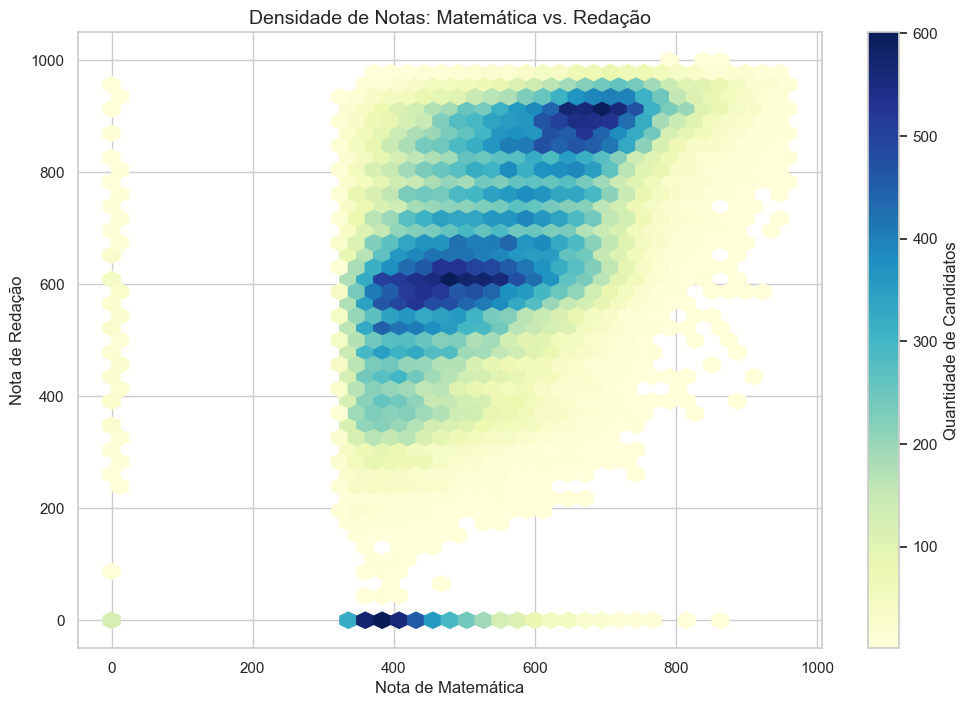

In [114]:
# 1. Definindo o tamanho da figura
plt.figure(figsize=(12, 8))

# 2. Criando o gráfico de hexágonos
hb = plt.hexbin(
    df['Score_Mathematics'], 
    df['Score_Essay'], 
    gridsize=40, 
    cmap='YlGnBu', 
    mincnt=1
)

# 3. Adicionando uma barra de cores para servir de legenda
cb = plt.colorbar(hb)
cb.set_label('Quantidade de Candidatos', fontsize=12)

# 4. Personalizando títulos e eixos
plt.title('Densidade de Notas: Matemática vs. Redação', fontsize=14)
plt.xlabel('Nota de Matemática', fontsize=12)
plt.ylabel('Nota de Redação', fontsize=12)

plt.show()